In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

In [3]:
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

/tmp/ipython-input-2882042334.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [4]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [5]:
data.columns=data.columns.droplevel(1)


In [6]:
data.reset_index(inplace=True)

In [7]:
data.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
1,2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2,2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
3,2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
4,2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [8]:
data.set_index('Date', inplace=True)

In [9]:
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.214888,24.682220,23.776348,24.671145,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534939,23.794075,23.173918,23.596954,263188400
2015-01-07,23.864950,23.964618,23.632391,23.743133,160423600
2015-01-08,24.781893,24.839479,24.075357,24.192745,237458000


In [10]:
data = data[['Close']]


In [11]:
data.head()

Price,Close
Date,
2015-01-02,24.214888
2015-01-05,23.532719
2015-01-06,23.534939
2015-01-07,23.864950
2015-01-08,24.781893


In [12]:
data.columns.name=None

In [13]:
data.head()

,Close
Date,
2015-01-02,24.214888
2015-01-05,23.532719
2015-01-06,23.534939
2015-01-07,23.864950
2015-01-08,24.781893


<Figure size 1200x600 with 0 Axes>

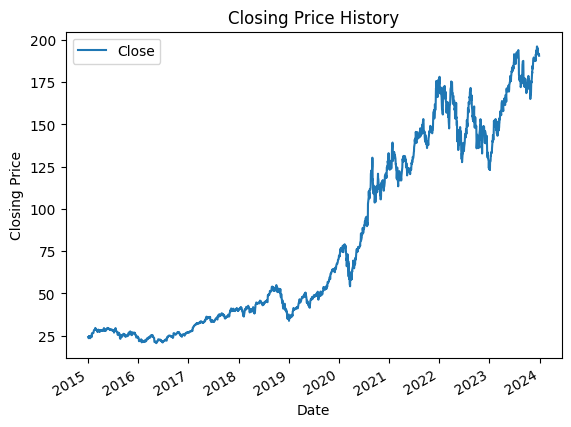

In [14]:
plt.figure(figsize=(12,6))
data.plot()
plt.title('Closing Price History')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

In [15]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)


In [16]:
X=[]
y=[]
for i in range(60,len(scaled_data)):
  X.append(scaled_data[i-60:i])
  y.append(scaled_data[i])

In [17]:
np.array(X).shape,np.array(y).shape

((2204, 60, 1), (2204, 1))

In [18]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(LSTM(50))
model.add(Dropout(0.2))

model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
import numpy as np

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(np.array(X_train), np.array(y_train), epochs=20, batch_size=32)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - loss: 0.0248
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0022
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0015
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0013
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0014
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0013
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0011
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 0.0012
Epoch 9/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.0013
Epoch 10/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0026
Epoch 11/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0013
Epoch 12/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0012
Epoch 13/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0011
Epoch 14/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0012
Epoch 15/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0012
Epo

In [21]:
prediction=model.predict(np.array(X_test))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [22]:
predicted = scaler.inverse_transform(prediction)
y_test = scaler.inverse_transform(np.array(y_test))

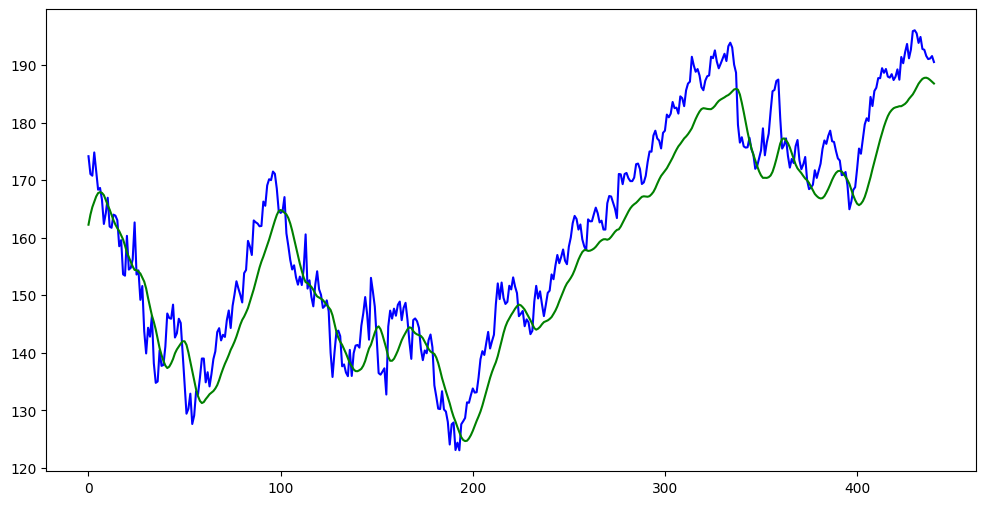

In [23]:
plt.figure(figsize=(12,6))
plt.plot(y_test,label="Actual Price" ,color='blue')
plt.plot(predicted, label="Predicted Price",color='green')
plt.legend
plt.show()
